In [1]:
from experiments.rag_exp_new import (
    RAGConfig, ChunkingConfig, EmbeddingConfig,
    RetrievalConfig, RerankConfig,
    load_and_prepare_docs, PageMapper, EvalDataLoader,
    SplitterFactory, run_experiments, ResultsVisualizer
)
import numpy as np
import pandas as pd

/home/yuri/HSE/ВКР/RAG/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

# ---------- Подготовка (один раз) ----------
docs = load_and_prepare_docs("./data")
page_mapper = PageMapper(docs)
eval_data = EvalDataLoader.load("./context/docs_questions_qwen3_14b_awq.jsonl",
                                skip_pages={72, 73, 74, 75, 76, 77, 78, 79, 80, 81})
splitter_factory = SplitterFactory("Qwen/Qwen3-Embedding-0.6B")


2026-05-01 15:47:32,190 - INFO - Пустые страницы: [34, 86]
2026-05-01 15:47:32,190 - INFO - Загружено 84 непустых страниц
2026-05-01 15:47:32,191 - INFO - Загружено 222 вопросов из ./context/docs_questions_qwen3_14b_awq.jsonl
2026-05-01 15:47:33,506 - INFO - Токенизатор: Qwen/Qwen3-Embedding-0.6B


In [ ]:

# ---------- Эксперимент 1: baseline (dense, без rerank) ----------
cfg_baseline = RAGConfig(name="dense_baseline")

# ---------- Эксперимент 2: dense + rerank ----------
cfg_rerank = RAGConfig(
    name="dense_rerank",
    retrieval=RetrievalConfig(mode="dense", retrieval_k=20),
    rerank=RerankConfig(
        enabled=True,
        api_base="http://localhost:8082",
        api_model_name="qwen3-rerank",
        top_n=5,
        backend="vllm",  # или "tei"
    ),
)

# ---------- Эксперимент 3: hybrid + rerank ----------
cfg_hybrid = RAGConfig(
    name="hybrid_rerank",
    retrieval=RetrievalConfig(mode="hybrid", retrieval_k=20),
    rerank=RerankConfig(enabled=True),
)

# ---------- Эксперимент 4: Matryoshka 256 dims ----------
cfg_matryoshka = RAGConfig(
    name="matryoshka_256",
    embedding=EmbeddingConfig(truncate_dim=256),
)

# ---------- Запуск ----------
df = run_experiments(
    configs=[cfg_baseline, cfg_rerank, cfg_hybrid, cfg_matryoshka],
    page_mapper=page_mapper,
    splitter_factory=splitter_factory,
    eval_data=eval_data,
    save_csv="../results/exp_rerank.csv",
)

# ---------- Графики ----------
ResultsVisualizer.compare_categories(
    df,
    category_col="retrieval_mode",  # или "rerank", или "experiment"
    label_col="experiment",
    title="Dense vs Hybrid vs Rerank",
)

2026-04-25 16:14:56,194 - INFO - 
Эксперимент: token_150_75
2026-04-25 16:14:57,363 - INFO - wb_token_150_75 уже существует, переиспользуем
Retrieve [token_150_75]: 100%|██████████| 222/222 [00:01<00:00, 131.55it/s]
2026-04-25 16:14:59,054 - INFO - Retrieval+rerank: 1.7s (0.01s на запрос)
2026-04-25 16:14:59,056 - INFO -   token_150_75 | k= 1 | P=0.649 R=0.649 F1=0.649 HR=0.649 MRR=0.649
2026-04-25 16:14:59,058 - INFO -   token_150_75 | k= 2 | P=0.565 R=0.743 F1=0.625 HR=0.743 MRR=0.696
2026-04-25 16:14:59,059 - INFO -   token_150_75 | k= 3 | P=0.501 R=0.779 F1=0.587 HR=0.779 MRR=0.708
2026-04-25 16:14:59,061 - INFO -   token_150_75 | k= 5 | P=0.425 R=0.847 F1=0.537 HR=0.847 MRR=0.724
2026-04-25 16:14:59,063 - INFO -   token_150_75 | k=10 | P=0.332 R=0.928 F1=0.464 HR=0.928 MRR=0.736
2026-04-25 16:14:59,067 - INFO - 
Эксперимент: token_328_75
2026-04-25 16:15:00,227 - INFO - wb_token_328_75 уже существует, переиспользуем
Retrieve [token_328_75]: 100%|██████████| 222/222 [00:01<00:00, 1

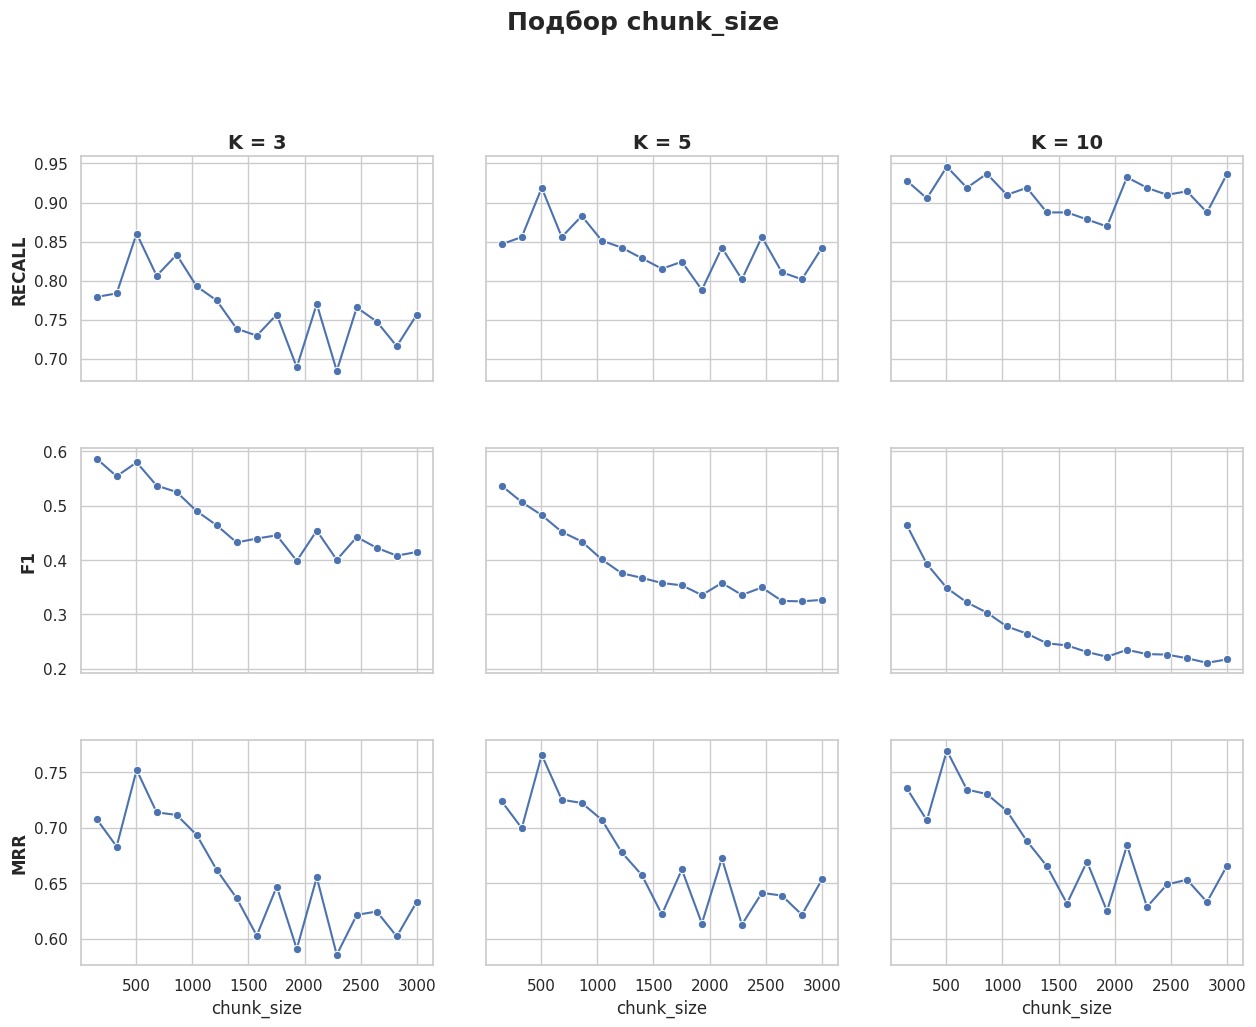

In [8]:
configs_cs = [
    RAGConfig(name=f"token_{cs}_75", chunking=ChunkingConfig(chunk_size=cs, chunk_overlap=75), recreate=False)
    for cs in np.linspace(150, 3000, 17, dtype=int)
]
results_cs =run_experiments(configs_cs, page_mapper, splitter_factory, eval_data,
                                   save_csv="./new_results/chunk_size_new.csv")
ResultsVisualizer.plot_by_variable(results_cs, x_col="chunk_size", title="Подбор chunk_size",save_path="./new_results/chunk_size_new.png", k_values=[3,5,10])

2026-04-25 16:27:07,281 - INFO - 
Эксперимент: token_506_50
2026-04-25 16:27:08,420 - INFO - wb_token_506_50 уже существует, переиспользуем
Retrieve [token_506_50]: 100%|██████████| 222/222 [00:01<00:00, 127.30it/s]
2026-04-25 16:27:10,167 - INFO - Retrieval+rerank: 1.7s (0.01s на запрос)
2026-04-25 16:27:10,168 - INFO -   token_506_50 | k= 1 | P=0.631 R=0.631 F1=0.631 HR=0.631 MRR=0.631
2026-04-25 16:27:10,169 - INFO -   token_506_50 | k= 2 | P=0.520 R=0.748 F1=0.596 HR=0.748 MRR=0.689
2026-04-25 16:27:10,171 - INFO -   token_506_50 | k= 3 | P=0.446 R=0.806 F1=0.552 HR=0.806 MRR=0.709
2026-04-25 16:27:10,172 - INFO -   token_506_50 | k= 5 | P=0.341 R=0.856 F1=0.467 HR=0.856 MRR=0.720
2026-04-25 16:27:10,174 - INFO -   token_506_50 | k=10 | P=0.210 R=0.905 F1=0.330 HR=0.905 MRR=0.727
2026-04-25 16:27:10,177 - INFO - 
Эксперимент: token_506_75
2026-04-25 16:27:11,359 - INFO - wb_token_506_75 уже существует, переиспользуем
Retrieve [token_506_75]: 100%|██████████| 222/222 [00:01<00:00, 1

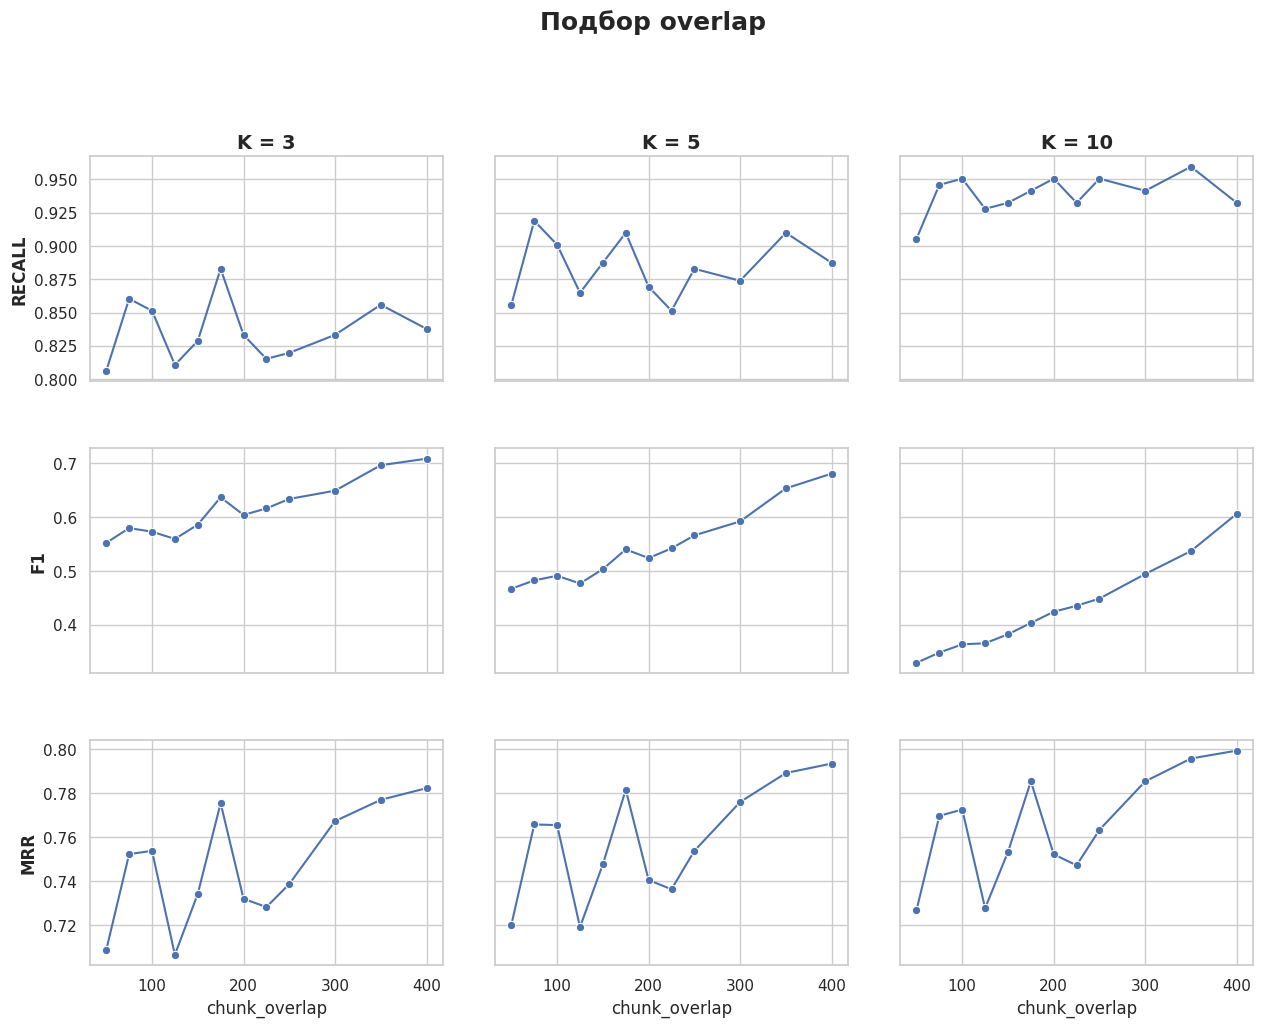

In [10]:
overlaps = [50, 75, 100, 125, 150, 175, 200, 225, 250, 300, 350, 400]

configs_overlap = [
    RAGConfig(
        name=f"token_506_{ov}",
        chunking=ChunkingConfig(chunk_size=506, chunk_overlap=ov, splitter_type="token"),
        recreate=False
    )
    for ov in overlaps
]

results_ov = run_experiments(configs=configs_overlap,
                                   page_mapper=page_mapper,
                                   splitter_factory=splitter_factory,
                                   eval_data=eval_data,
                                   save_csv="./new_results/overlap_new.csv",)

ResultsVisualizer.plot_by_variable(results_ov, x_col="chunk_overlap", title="Подбор overlap", save_path="./new_results/overlap_new.png", k_values=[3,5,10])

## Эксперимент. Модель rerank bge-reranker-v2-m3

### Эксперимент. F2LLM + rerank bge-reranker-v2-m3

2026-04-25 22:12:33,524 - INFO - 
Эксперимент: F2LLM-v2-0.6B-rerank
2026-04-25 22:12:33,525 - INFO - Embedding: codefuse-ai/F2LLM-v2-0.6B @ http://localhost:8081/v1
Generating embeddings: 100%|██████████| 238/238 [00:00<00:00, 480.97it/s]
2026-04-25 22:13:01,420 - INFO - wb_F2LLM-v2-0.6B-rerank: проиндексировано 2286 чанков
Retrieve [F2LLM-v2-0.6B-rerank]: 100%|██████████| 222/222 [00:06<00:00, 32.99it/s]
2026-04-25 22:13:08,152 - INFO - Retrieval+rerank: 6.7s (0.03s на запрос)
2026-04-25 22:13:08,155 - INFO -   F2LLM-v2-0.6B-rerank | k= 1 | P=0.847 R=0.847 F1=0.847 HR=0.847 MRR=0.847
2026-04-25 22:13:08,156 - INFO -   F2LLM-v2-0.6B-rerank | k= 2 | P=0.813 R=0.914 F1=0.847 HR=0.914 MRR=0.881
2026-04-25 22:13:08,158 - INFO -   F2LLM-v2-0.6B-rerank | k= 3 | P=0.766 R=0.937 F1=0.823 HR=0.937 MRR=0.888
2026-04-25 22:13:08,159 - INFO -   F2LLM-v2-0.6B-rerank | k= 5 | P=0.621 R=0.969 F1=0.728 HR=0.969 MRR=0.896
2026-04-25 22:13:08,161 - INFO -   F2LLM-v2-0.6B-rerank | k=10 | P=0.310 R=0.969 

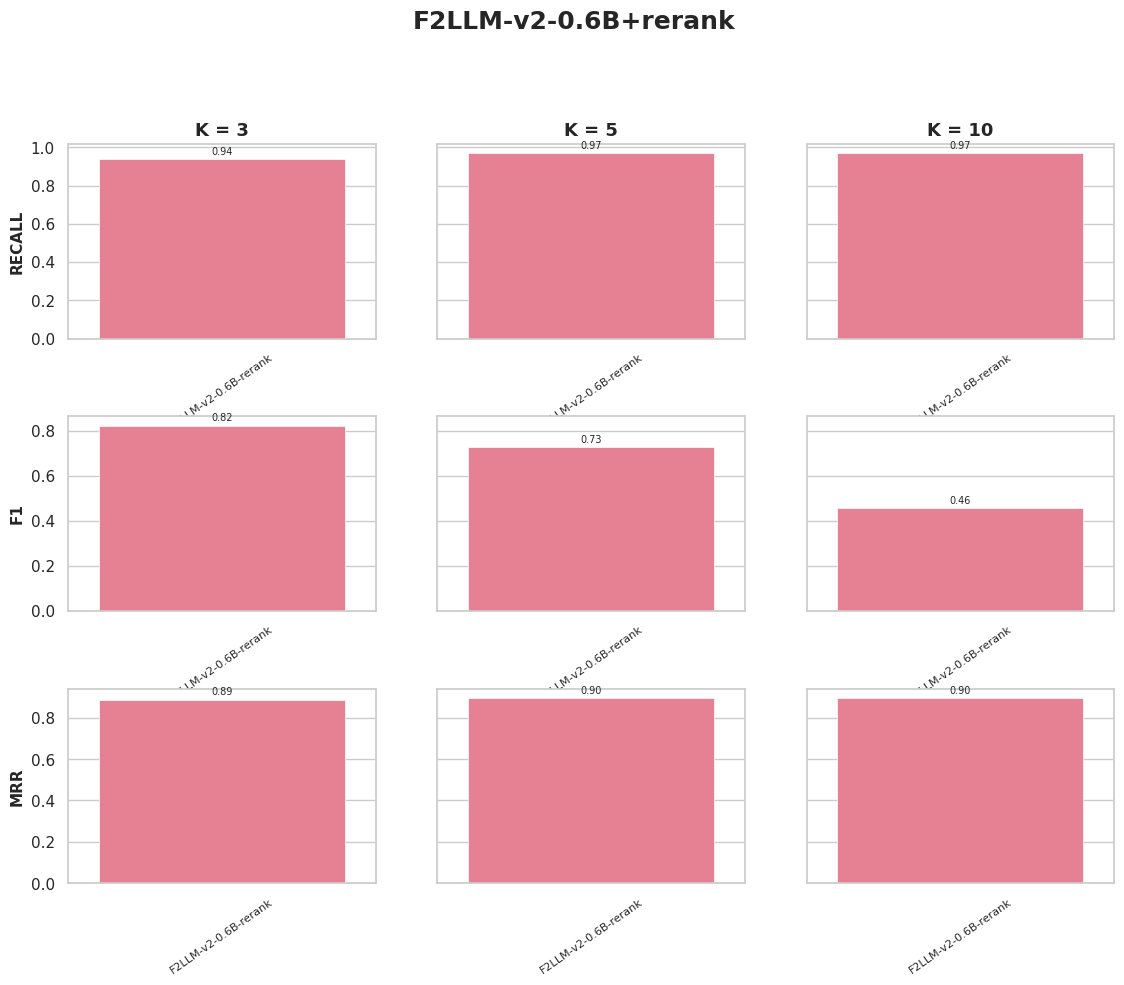

In [11]:
configs_sp = [
    RAGConfig(name="F2LLM-v2-0.6B-rerank", 
              chunking=ChunkingConfig(splitter_type="hierarchical", hierarchy_sizes=[512, 256, 128]),
              embedding=EmbeddingConfig(model_name="codefuse-ai/F2LLM-v2-0.6B",
                                        api_model_name="harr-embed"),
              rerank=RerankConfig(enabled=True,
                                  model_name="BAAI/bge-reranker-v2-m3",
                                  backend="tei")
              ),
]
results_sp = run_experiments(configs_sp, page_mapper, splitter_factory, eval_data,
                                   save_csv="./new_results/F2LLM-v2-0.6B-rerank.csv")
ResultsVisualizer.compare_categories(results_sp,
                                     title="F2LLM-v2-0.6B+rerank",
                                     category_col="experiment",
                                     k_values=[3,5,10],
                                     save_path="./new_results/F2LLM-v2-0.6B-rerank.png")

2026-04-26 11:04:06,066 - INFO - 
Эксперимент: F2LLM-v2-0.6B-rerank
2026-04-26 11:04:06,238 - INFO - Embedding: codefuse-ai/F2LLM-v2-0.6B @ http://localhost:8081/v1
2026-04-26 11:04:06,844 - INFO - wb_F2LLM-v2-0.6B-rerank уже существует, переиспользуем
Retrieve [F2LLM-v2-0.6B-rerank]: 100%|██████████| 222/222 [00:28<00:00,  7.91it/s]
2026-04-26 11:04:34,918 - INFO - Retrieval+rerank: 28.1s (0.13s на запрос)
2026-04-26 11:04:34,921 - INFO -   F2LLM-v2-0.6B-rerank | k= 1 | P=0.847 R=0.847 F1=0.847 HR=0.847 MRR=0.847
2026-04-26 11:04:34,922 - INFO -   F2LLM-v2-0.6B-rerank | k= 2 | P=0.813 R=0.914 F1=0.847 HR=0.914 MRR=0.881
2026-04-26 11:04:34,923 - INFO -   F2LLM-v2-0.6B-rerank | k= 3 | P=0.766 R=0.937 F1=0.823 HR=0.937 MRR=0.888
2026-04-26 11:04:34,924 - INFO -   F2LLM-v2-0.6B-rerank | k= 5 | P=0.620 R=0.969 F1=0.727 HR=0.969 MRR=0.896
2026-04-26 11:04:34,927 - INFO -   F2LLM-v2-0.6B-rerank | k=10 | P=0.444 R=0.982 F1=0.582 HR=0.982 MRR=0.898
2026-04-26 11:04:34,930 - INFO - Сохранено: 

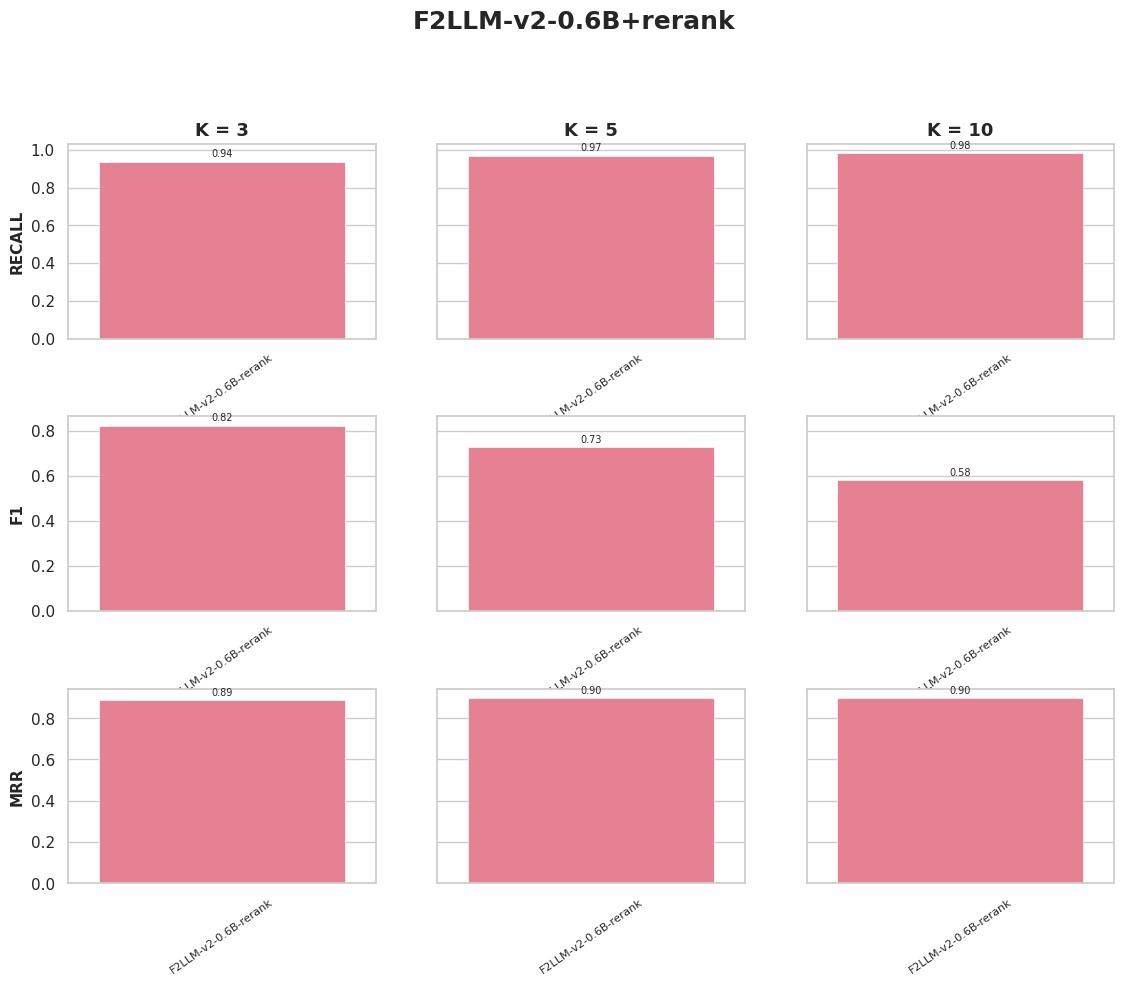

In [4]:
configs_sp = [
    RAGConfig(name="F2LLM-v2-0.6B-rerank", 
              chunking=ChunkingConfig(splitter_type="hierarchical", hierarchy_sizes=[512, 256, 128]),
              embedding=EmbeddingConfig(model_name="codefuse-ai/F2LLM-v2-0.6B",
                                        api_model_name="harr-embed"),
              rerank=RerankConfig(enabled=True,
                                  model_name="BAAI/bge-reranker-v2-m3",
                                  backend="tei",
                                  top_n=10),
              recreate=False
              ),
]
results_sp = run_experiments(configs_sp, page_mapper, splitter_factory, eval_data,
                                   save_csv="./new_results/F2LLM-v2-0.6B-rerank.csv")
ResultsVisualizer.compare_categories(results_sp,
                                     title="F2LLM-v2-0.6B+rerank",
                                     category_col="experiment",
                                     k_values=[3,5,10],
                                     save_path="./new_results/F2LLM-v2-0.6B-rerank.png")

### Эксперимент. Qwen3-embedding-0.6b + rerank bge-reranker-v2-m3

2026-04-26 11:12:12,094 - INFO - 
Эксперимент: Qwen3-Embedding-0.6B-rerank
Generating embeddings: 100%|██████████| 238/238 [00:00<00:00, 477.51it/s]
2026-04-26 11:12:39,766 - INFO - wb_Qwen3-Embedding-0.6B-rerank: проиндексировано 2286 чанков
Retrieve [Qwen3-Embedding-0.6B-rerank]: 100%|██████████| 222/222 [00:06<00:00, 35.27it/s]
2026-04-26 11:12:46,063 - INFO - Retrieval+rerank: 6.3s (0.03s на запрос)
2026-04-26 11:12:46,064 - INFO -   Qwen3-Embedding-0.6B-rerank | k= 1 | P=0.829 R=0.829 F1=0.829 HR=0.829 MRR=0.829
2026-04-26 11:12:46,066 - INFO -   Qwen3-Embedding-0.6B-rerank | k= 2 | P=0.824 R=0.910 F1=0.853 HR=0.910 MRR=0.869
2026-04-26 11:12:46,067 - INFO -   Qwen3-Embedding-0.6B-rerank | k= 3 | P=0.764 R=0.937 F1=0.822 HR=0.937 MRR=0.878
2026-04-26 11:12:46,068 - INFO -   Qwen3-Embedding-0.6B-rerank | k= 5 | P=0.635 R=0.960 F1=0.736 HR=0.960 MRR=0.884
2026-04-26 11:12:46,070 - INFO -   Qwen3-Embedding-0.6B-rerank | k=10 | P=0.440 R=0.960 F1=0.575 HR=0.960 MRR=0.884
2026-04-26 11

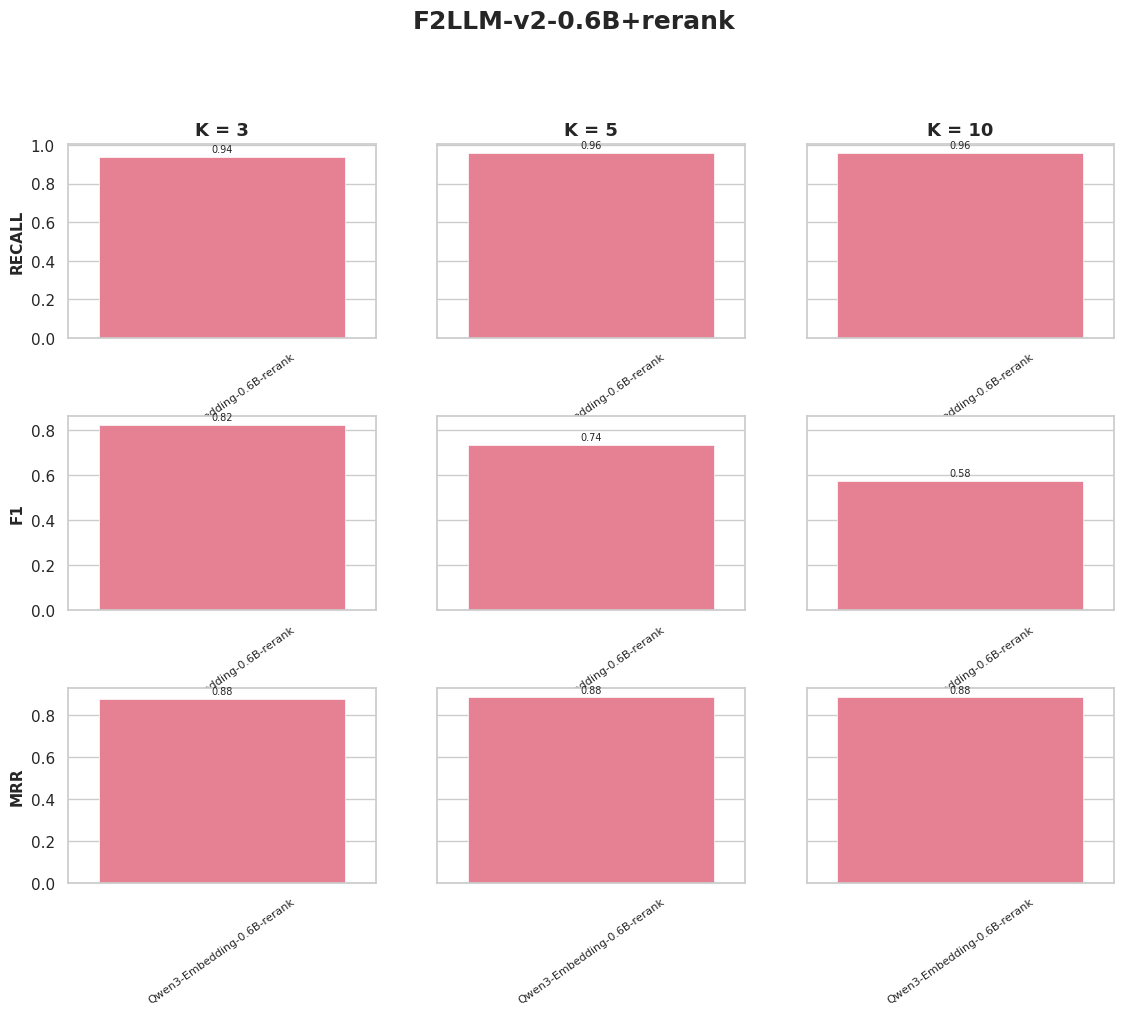

In [ ]:
configs_sp = [
    RAGConfig(name="Qwen3-Embedding-0.6B-rerank", 
              chunking=ChunkingConfig(splitter_type="hierarchical", hierarchy_sizes=[512, 256, 128]),
              embedding=EmbeddingConfig(model_name="Qwen/Qwen3-Embedding-0.6B",
                                        api_model_name="harr-embed"),
              rerank=RerankConfig(enabled=True,
                                  model_name="BAAI/bge-reranker-v2-m3",
                                  backend="tei",
                                  top_n=10),
              recreate=False
              ),
]
results_sp = run_experiments(configs_sp, page_mapper, splitter_factory, eval_data,
                                   save_csv="./new_results/Qwen3-Embedding-0.6B-rerank.csv")
ResultsVisualizer.compare_categories(results_sp,
                                     title="Qwen3-Embedding-0.6B+rerank",
                                     category_col="experiment",
                                     k_values=[3,5,10],
                                     save_path="./new_results/Qwen3-Embedding-0.6B-rerank.png")

### Эксперимент. Bge-m3 + rerank bge-reranker-v2-m3

2026-04-26 12:49:01,755 - INFO - 
Эксперимент: bge-m3-rerank
Generating embeddings: 100%|██████████| 238/238 [00:00<00:00, 721.15it/s]
2026-04-26 12:49:14,308 - INFO - wb_bge-m3-rerank: проиндексировано 2286 чанков
Retrieve [bge-m3-rerank]: 100%|██████████| 222/222 [00:06<00:00, 32.24it/s]
2026-04-26 12:49:21,196 - INFO - Retrieval+rerank: 6.9s (0.03s на запрос)
2026-04-26 12:49:21,198 - INFO -   bge-m3-rerank | k= 1 | P=0.851 R=0.851 F1=0.851 HR=0.851 MRR=0.851
2026-04-26 12:49:21,199 - INFO -   bge-m3-rerank | k= 2 | P=0.829 R=0.914 F1=0.857 HR=0.914 MRR=0.883
2026-04-26 12:49:21,200 - INFO -   bge-m3-rerank | k= 3 | P=0.778 R=0.928 F1=0.829 HR=0.928 MRR=0.887
2026-04-26 12:49:21,202 - INFO -   bge-m3-rerank | k= 5 | P=0.640 R=0.955 F1=0.743 HR=0.955 MRR=0.894
2026-04-26 12:49:21,204 - INFO -   bge-m3-rerank | k=10 | P=0.451 R=0.964 F1=0.586 HR=0.964 MRR=0.895
2026-04-26 12:49:21,209 - INFO - Сохранено: ./new_results/bge-m3-rerank.csv
2026-04-26 12:49:21,606 - INFO - График: ./new_re

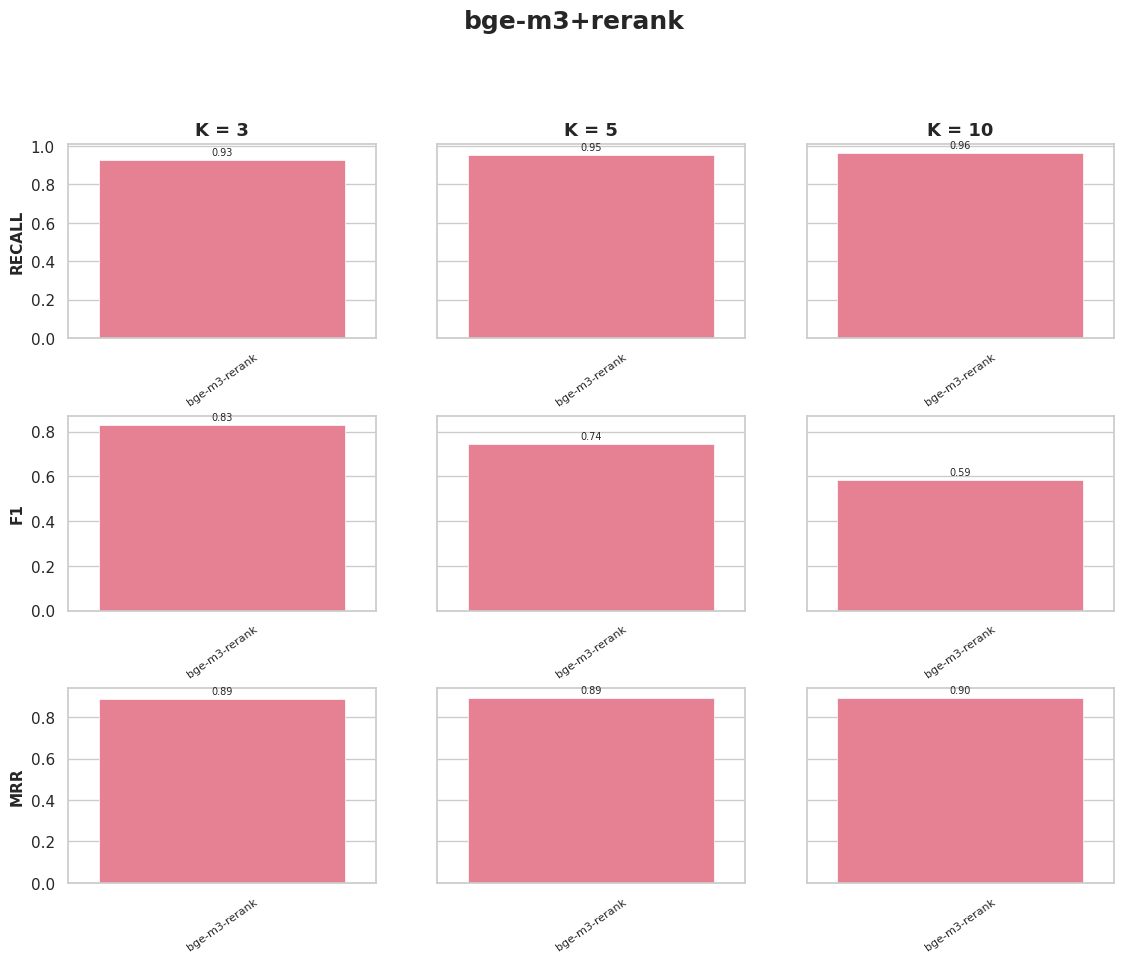

In [6]:
configs_sp = [
    RAGConfig(name="bge-m3-rerank", 
              chunking=ChunkingConfig(splitter_type="hierarchical", hierarchy_sizes=[512, 256, 128]),
              embedding=EmbeddingConfig(model_name="BAAI/bge-m3",
                                        api_model_name="harr-embed"),
              rerank=RerankConfig(enabled=True,
                                  model_name="BAAI/bge-reranker-v2-m3",
                                  backend="tei",
                                  top_n=10),
              recreate=False
              ),
]
results_sp = run_experiments(configs_sp, page_mapper, splitter_factory, eval_data,
                                   save_csv="./new_results/bge-m3-rerank.csv")
ResultsVisualizer.compare_categories(results_sp,
                                     title="bge-m3+rerank",
                                     category_col="experiment",
                                     k_values=[3,5,10],
                                     save_path="./new_results/bge-m3-rerank.png")

### Эксперимент. jinaai/jina-embeddings-v3 + rerank

2026-04-29 16:06:29,445 - INFO - 
Эксперимент: jina-embeddings-v3-rerank
2026-04-29 16:06:29,707 - INFO - Embedding: jinaai/jina-embeddings-v3 @ http://localhost:8081/v1
Generating embeddings: 100%|██████████| 238/238 [00:00<00:00, 652.65it/s]
2026-04-29 16:06:43,567 - INFO - wb_jina-embeddings-v3-rerank: проиндексировано 2286 чанков
Retrieve [jina-embeddings-v3-rerank]: 100%|██████████| 222/222 [00:06<00:00, 33.99it/s]
2026-04-29 16:06:50,101 - INFO - Retrieval+rerank: 6.5s (0.03s на запрос)
2026-04-29 16:06:50,109 - INFO -   jina-embeddings-v3-rerank | k= 1 | P=0.820 R=0.820 F1=0.820 HR=0.820 MRR=0.820
2026-04-29 16:06:50,111 - INFO -   jina-embeddings-v3-rerank | k= 2 | P=0.804 R=0.878 F1=0.829 HR=0.878 MRR=0.849
2026-04-29 16:06:50,112 - INFO -   jina-embeddings-v3-rerank | k= 3 | P=0.742 R=0.910 F1=0.796 HR=0.910 MRR=0.860
2026-04-29 16:06:50,113 - INFO -   jina-embeddings-v3-rerank | k= 5 | P=0.614 R=0.937 F1=0.715 HR=0.937 MRR=0.866
2026-04-29 16:06:50,115 - INFO -   jina-embedd

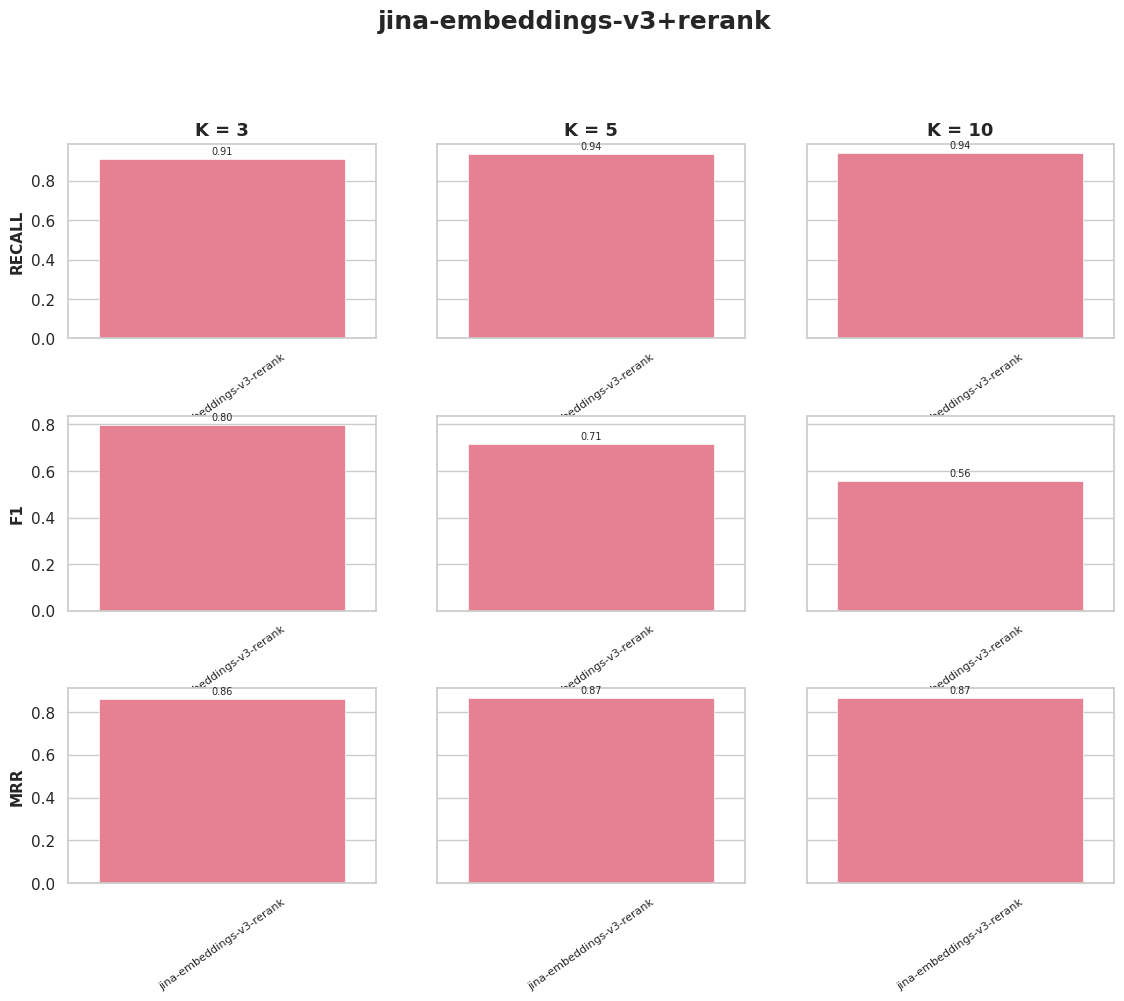

In [7]:
configs_sp = [
    RAGConfig(name="jina-embeddings-v3-rerank", 
              chunking=ChunkingConfig(splitter_type="hierarchical", hierarchy_sizes=[512, 256, 128]),
              embedding=EmbeddingConfig(model_name="jinaai/jina-embeddings-v3",
                                        api_model_name="harr-embed"),
              rerank=RerankConfig(enabled=True,
                                  model_name="BAAI/bge-reranker-v2-m3",
                                  backend="tei",
                                  top_n=10),
              recreate=False
              ),
]
results_sp = run_experiments(configs_sp, page_mapper, splitter_factory, eval_data,
                                   save_csv="./new_results/jina-embeddings-v3-rerank.csv")
ResultsVisualizer.compare_categories(results_sp,
                                     title="jina-embeddings-v3+rerank",
                                     category_col="experiment",
                                     k_values=[3,5,10],
                                     save_path="./new_results/jina-embeddings-v3-rerank.png")

### Эксперимент. intfloat/multilingual-e5-large-instruct + rerank

2026-04-29 16:11:53,657 - INFO - 
Эксперимент: multilingual-e5-large-instruct+rerank
Generating embeddings: 100%|██████████| 238/238 [00:00<00:00, 701.77it/s]
2026-04-29 16:12:06,609 - INFO - wb_multilingual-e5-large-instruct+rerank: проиндексировано 2286 чанков
Retrieve [multilingual-e5-large-instruct+rerank]: 100%|██████████| 222/222 [00:05<00:00, 38.20it/s]
2026-04-29 16:12:12,423 - INFO - Retrieval+rerank: 5.8s (0.03s на запрос)
2026-04-29 16:12:12,426 - INFO -   multilingual-e5-large-instruct+rerank | k= 1 | P=0.842 R=0.842 F1=0.842 HR=0.842 MRR=0.842
2026-04-29 16:12:12,427 - INFO -   multilingual-e5-large-instruct+rerank | k= 2 | P=0.790 R=0.910 F1=0.830 HR=0.910 MRR=0.876
2026-04-29 16:12:12,429 - INFO -   multilingual-e5-large-instruct+rerank | k= 3 | P=0.734 R=0.928 F1=0.796 HR=0.928 MRR=0.882
2026-04-29 16:12:12,431 - INFO -   multilingual-e5-large-instruct+rerank | k= 5 | P=0.612 R=0.960 F1=0.715 HR=0.960 MRR=0.890
2026-04-29 16:12:12,433 - INFO -   multilingual-e5-large-in

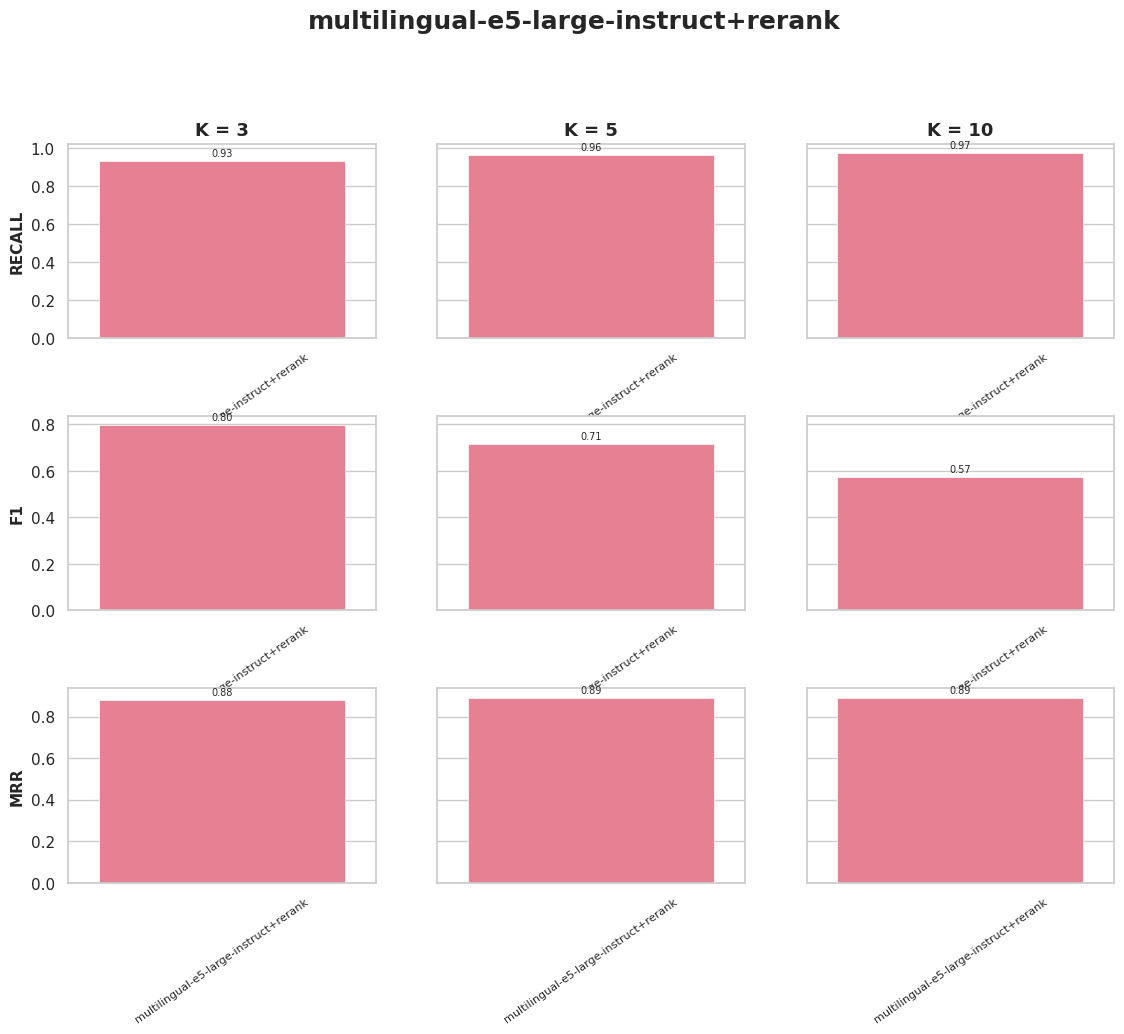

In [11]:
configs_sp = [
    RAGConfig(name="multilingual-e5-large-instruct+rerank", 
              chunking=ChunkingConfig(splitter_type="hierarchical", hierarchy_sizes=[512, 256, 128]),
              embedding=EmbeddingConfig(model_name="intfloat/multilingual-e5-large-instruct",
                                        api_model_name="harr-embed"),
              rerank=RerankConfig(enabled=True,
                                  model_name="BAAI/bge-reranker-v2-m3",
                                  backend="tei",
                                  top_n=10),
              recreate=False
              ),
]
results_sp = run_experiments(configs_sp, page_mapper, splitter_factory, eval_data,
                                   save_csv="./new_results/multilingual-e5-large-instruct-rerank.csv")
ResultsVisualizer.compare_categories(results_sp,
                                     title="multilingual-e5-large-instruct+rerank",
                                     category_col="experiment",
                                     k_values=[3,5,10],
                                     save_path="./new_results/multilingual-e5-large-instruct-rerank.png")

### Эксперимент. Сравнение embed моделей + rerank

In [12]:
df_bge = pd.read_csv("./new_results/bge-m3-rerank.csv")
df_f2llm = pd.read_csv("./new_results/F2LLM-v2-0.6B-rerank.csv")
df_qwen3 = pd.read_csv("./new_results/Qwen3-Embedding-0.6B-rerank.csv")
df_jina = pd.read_csv("./new_results/jina-embeddings-v3-rerank.csv")
df_multi = pd.read_csv("./new_results/multilingual-e5-large-instruct-rerank.csv")

2026-04-29 16:12:42,305 - INFO - График: ./new_results/rerank_bge_vs_qwen3_vs_f2.png


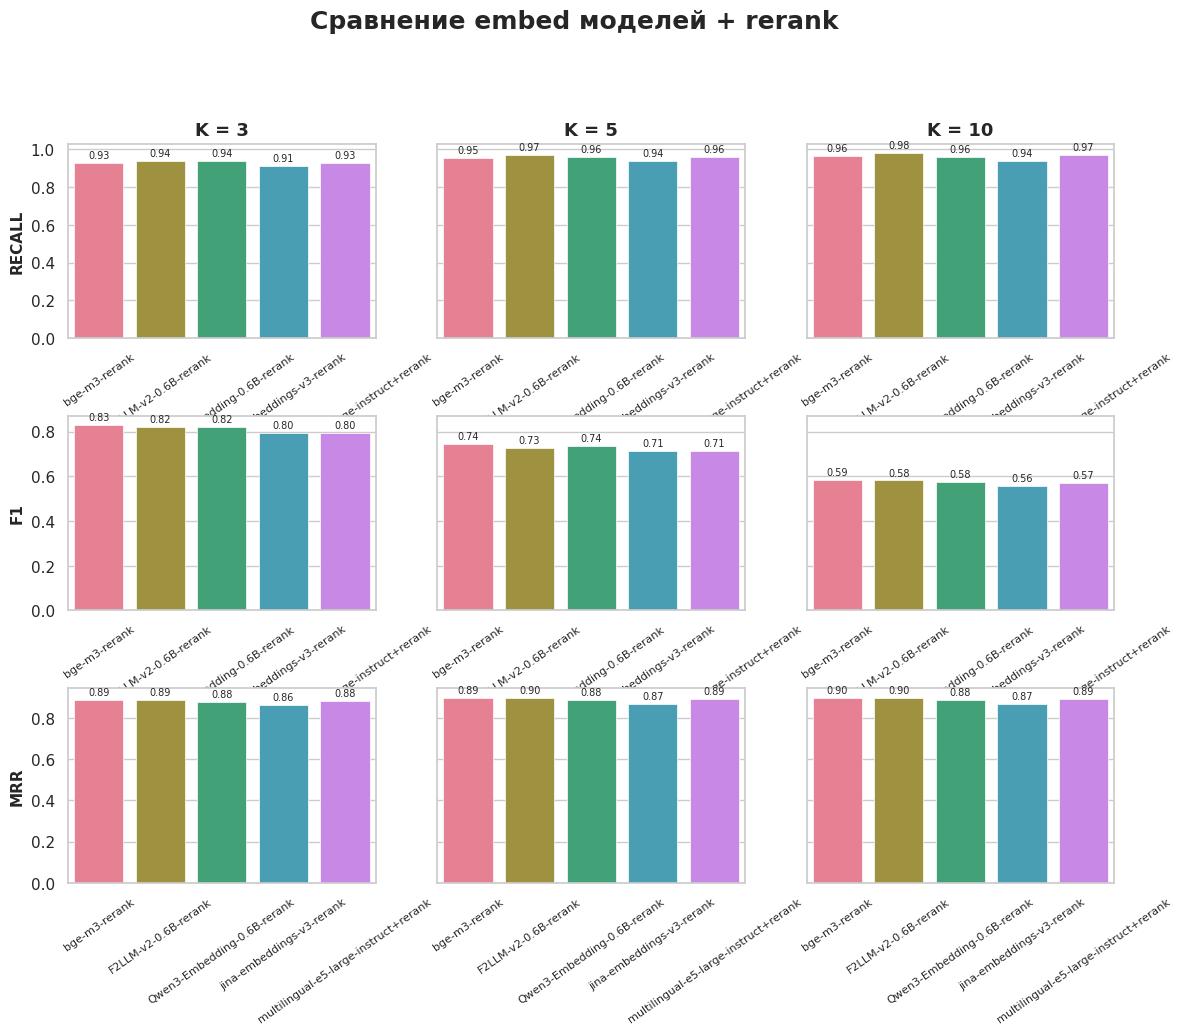

In [13]:
df_all_models = pd.concat([df_bge, df_f2llm, df_qwen3, df_jina, df_multi])
df_all_models["experiment"] = df_all_models["experiment"].str.replace("_hier_small", "")
ResultsVisualizer.compare_categories(df_all_models,
                                     title="Сравнение embed моделей + rerank",
                                     category_col="experiment",
                                     k_values=[3,5,10],
                                     save_path="./new_results/rerank_bge_vs_qwen3_vs_f2.png")

## Эксперимент. Модель rerank jinaai/jina-reranker-v3

### Эксперимент. 

2026-04-30 13:38:58,895 - INFO - 
Эксперимент: multilingual-e5+qwen3rerank
2026-04-30 13:38:59,041 - INFO - Embedding: intfloat/multilingual-e5-large-instruct @ http://localhost:8081/v1
2026-04-30 13:38:59,568 - INFO - wb_multilingual-e5+qwen3rerank уже существует, переиспользуем
2026-04-30 13:39:01,265 - INFO - Reranker loaded: tomaarsen/Qwen3-Reranker-0.6B-seq-cls on cuda
Retrieve [multilingual-e5+qwen3rerank]: 100%|██████████| 222/222 [01:29<00:00,  2.48it/s]
2026-04-30 13:40:30,927 - INFO - Retrieval+rerank: 89.7s (0.40s на запрос)
2026-04-30 13:40:30,929 - INFO -   multilingual-e5+qwen3rerank | k= 1 | P=0.761 R=0.761 F1=0.761 HR=0.761 MRR=0.761
2026-04-30 13:40:30,930 - INFO -   multilingual-e5+qwen3rerank | k= 2 | P=0.728 R=0.883 F1=0.779 HR=0.883 MRR=0.822
2026-04-30 13:40:30,931 - INFO -   multilingual-e5+qwen3rerank | k= 3 | P=0.671 R=0.928 F1=0.752 HR=0.928 MRR=0.837
2026-04-30 13:40:30,933 - INFO -   multilingual-e5+qwen3rerank | k= 5 | P=0.569 R=0.951 F1=0.681 HR=0.951 MRR=

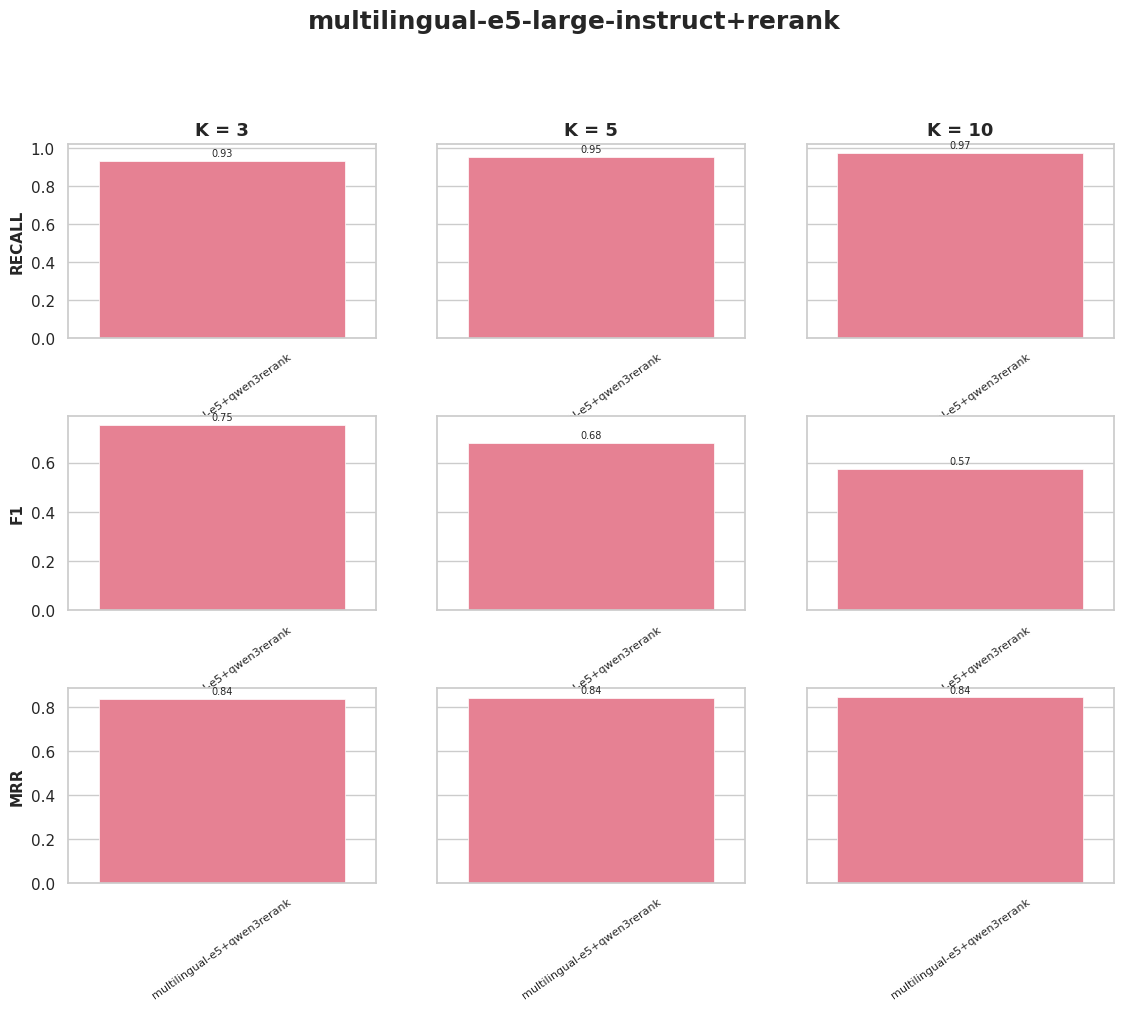

In [5]:
configs_sp = [
    RAGConfig(name="multilingual-e5+qwen3rerank", 
              chunking=ChunkingConfig(splitter_type="hierarchical", hierarchy_sizes=[512, 256, 128]),
              embedding=EmbeddingConfig(model_name="intfloat/multilingual-e5-large-instruct",
                                        api_model_name="harr-embed"),
              rerank=RerankConfig(enabled=True,
                                  model_name="tomaarsen/Qwen3-Reranker-0.6B-seq-cls",
                                  api_model_name="harr-rerank",
                                  prompt_template="qwen3",
                                  backend="local",
                                  top_n=10),
              recreate=False
              ),
]
results_sp = run_experiments(configs_sp, page_mapper, splitter_factory, eval_data,
                                   save_csv="./new_results/multilingual-e5-qwen3rerank.csv")
ResultsVisualizer.compare_categories(results_sp,
                                     title="multilingual-e5-large-instruct+rerank",
                                     category_col="experiment",
                                     k_values=[3,5,10],
                                     save_path="./new_results/multilingual-e5-qwen3rerank.png")

In [4]:
# В ноутбуке между экспериментами:
import gc, torch
# del RAGConfig.rerank  # или reranker = None
gc.collect()
torch.cuda.empty_cache()

### Эксперимент Qwen3-Embedding-0.6B+rerank

2026-05-01 16:00:24,200 - INFO - 
Эксперимент: Qwen3-Embedding-0.6B+jinav3rerank
2026-05-01 16:00:24,200 - INFO - Embedding: Qwen/Qwen3-Embedding-0.6B @ http://localhost:8081/v1
Generating embeddings: 100%|██████████| 238/238 [00:00<00:00, 442.66it/s]
2026-05-01 16:00:32,331 - INFO - wb_Qwen3-Embedding-0.6B+jinav3rerank: проиндексировано 2286 чанков
2026-05-01 16:00:34,480 - INFO - Jina V3 Reranker loaded: jinaai/jina-reranker-v3 on cuda
Retrieve [Qwen3-Embedding-0.6B+jinav3rerank]: 100%|██████████| 222/222 [00:19<00:00, 11.29it/s]
2026-05-01 16:00:54,144 - INFO - Retrieval+rerank: 19.7s (0.09s на запрос)
2026-05-01 16:00:54,147 - INFO -   Qwen3-Embedding-0.6B+jinav3rerank | k= 1 | P=0.842 R=0.842 F1=0.842 HR=0.842 MRR=0.842
2026-05-01 16:00:54,149 - INFO -   Qwen3-Embedding-0.6B+jinav3rerank | k= 2 | P=0.795 R=0.923 F1=0.838 HR=0.923 MRR=0.883
2026-05-01 16:00:54,150 - INFO -   Qwen3-Embedding-0.6B+jinav3rerank | k= 3 | P=0.755 R=0.941 F1=0.818 HR=0.941 MRR=0.889
2026-05-01 16:00:54,1

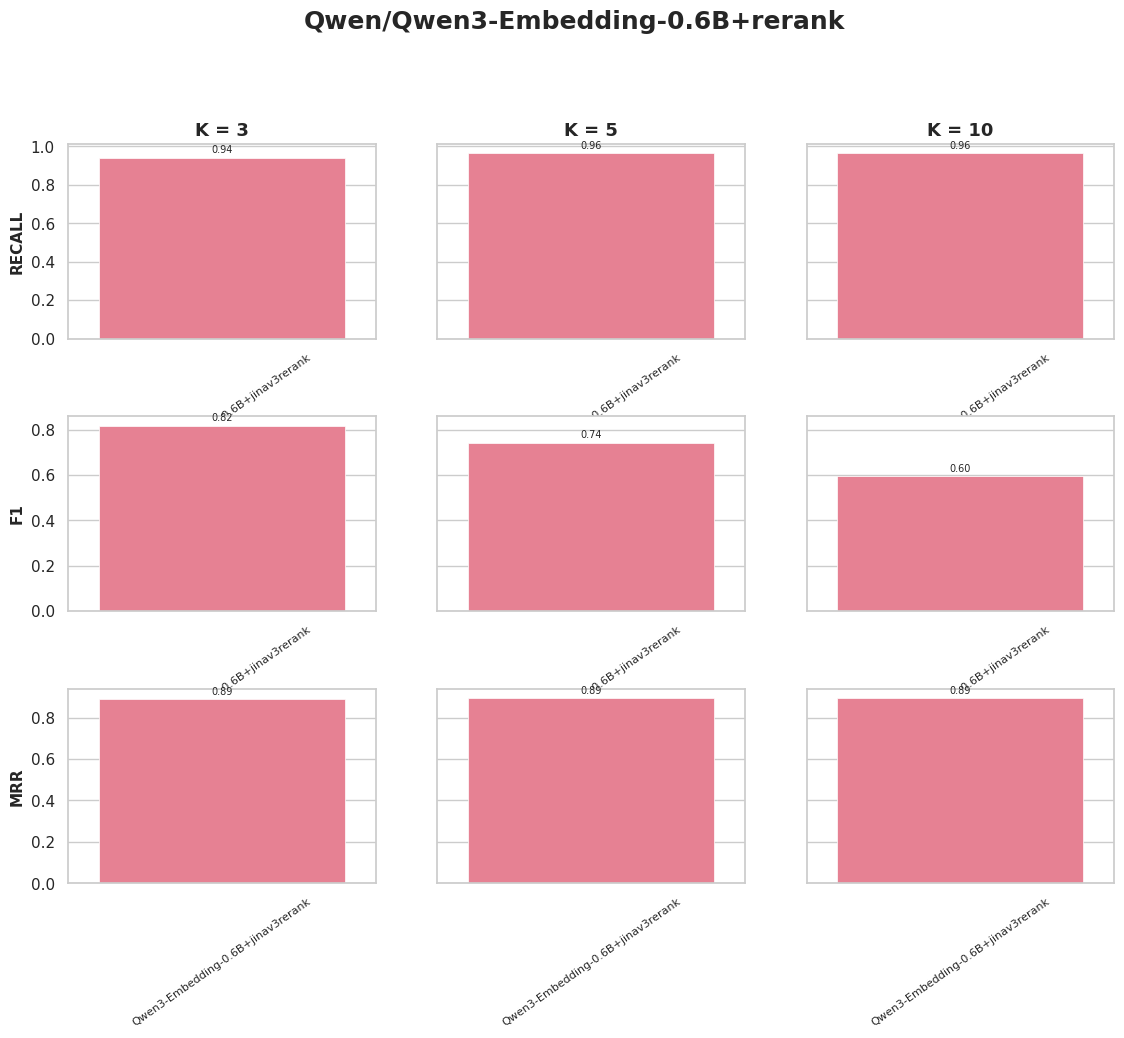

In [6]:
configs_sp = [
    RAGConfig(name="Qwen3-Embedding-0.6B+jinav3rerank", 
              chunking=ChunkingConfig(splitter_type="hierarchical", hierarchy_sizes=[512, 256, 128]),
              embedding=EmbeddingConfig(model_name="Qwen/Qwen3-Embedding-0.6B",
                                        api_model_name="qwen3-embed"),
              rerank=RerankConfig(enabled=True,
                                  model_name="jinaai/jina-reranker-v3",
                                #   api_model_name="harr-rerank",
                                #   prompt_template="qwen3",
                                  backend="jina_v3",
                                  device="cuda",
                                  top_n=10),
              recreate=False
              ),
]
results_sp = run_experiments(configs_sp, page_mapper, splitter_factory, eval_data,
                                   save_csv="./new_results/Qwen3-Embedding-0.6B-jinav3rerank.csv")
ResultsVisualizer.compare_categories(results_sp,
                                     title="Qwen/Qwen3-Embedding-0.6B+rerank",
                                     category_col="experiment",
                                     k_values=[3,5,10],
                                     save_path="./new_results/Qwen3-Embedding-0.6B-jinav3rerank.png")

### Эксперимент. 

2026-04-30 16:47:22,451 - INFO - 
Эксперимент: Qwen3-Embedding-0.6B+qwen3rerank
2026-04-30 16:47:22,855 - INFO - wb_Qwen3-Embedding-0.6B+qwen3rerank уже существует, переиспользуем
`torch_dtype` is deprecated! Use `dtype` instead!
2026-04-30 16:47:28,913 - INFO - LLM Reranker loaded: jinaai/jina-reranker-v3 on cuda
Retrieve [Qwen3-Embedding-0.6B+qwen3rerank]: 100%|██████████| 222/222 [00:40<00:00,  5.51it/s]
2026-04-30 16:48:09,181 - INFO - Retrieval+rerank: 40.3s (0.18s на запрос)
2026-04-30 16:48:09,182 - INFO -   Qwen3-Embedding-0.6B+qwen3rerank | k= 1 | P=0.396 R=0.396 F1=0.396 HR=0.396 MRR=0.396
2026-04-30 16:48:09,184 - INFO -   Qwen3-Embedding-0.6B+qwen3rerank | k= 2 | P=0.387 R=0.554 F1=0.443 HR=0.554 MRR=0.475
2026-04-30 16:48:09,185 - INFO -   Qwen3-Embedding-0.6B+qwen3rerank | k= 3 | P=0.383 R=0.658 F1=0.463 HR=0.658 MRR=0.510
2026-04-30 16:48:09,186 - INFO -   Qwen3-Embedding-0.6B+qwen3rerank | k= 5 | P=0.384 R=0.833 F1=0.498 HR=0.833 MRR=0.550
2026-04-30 16:48:09,189 - INFO

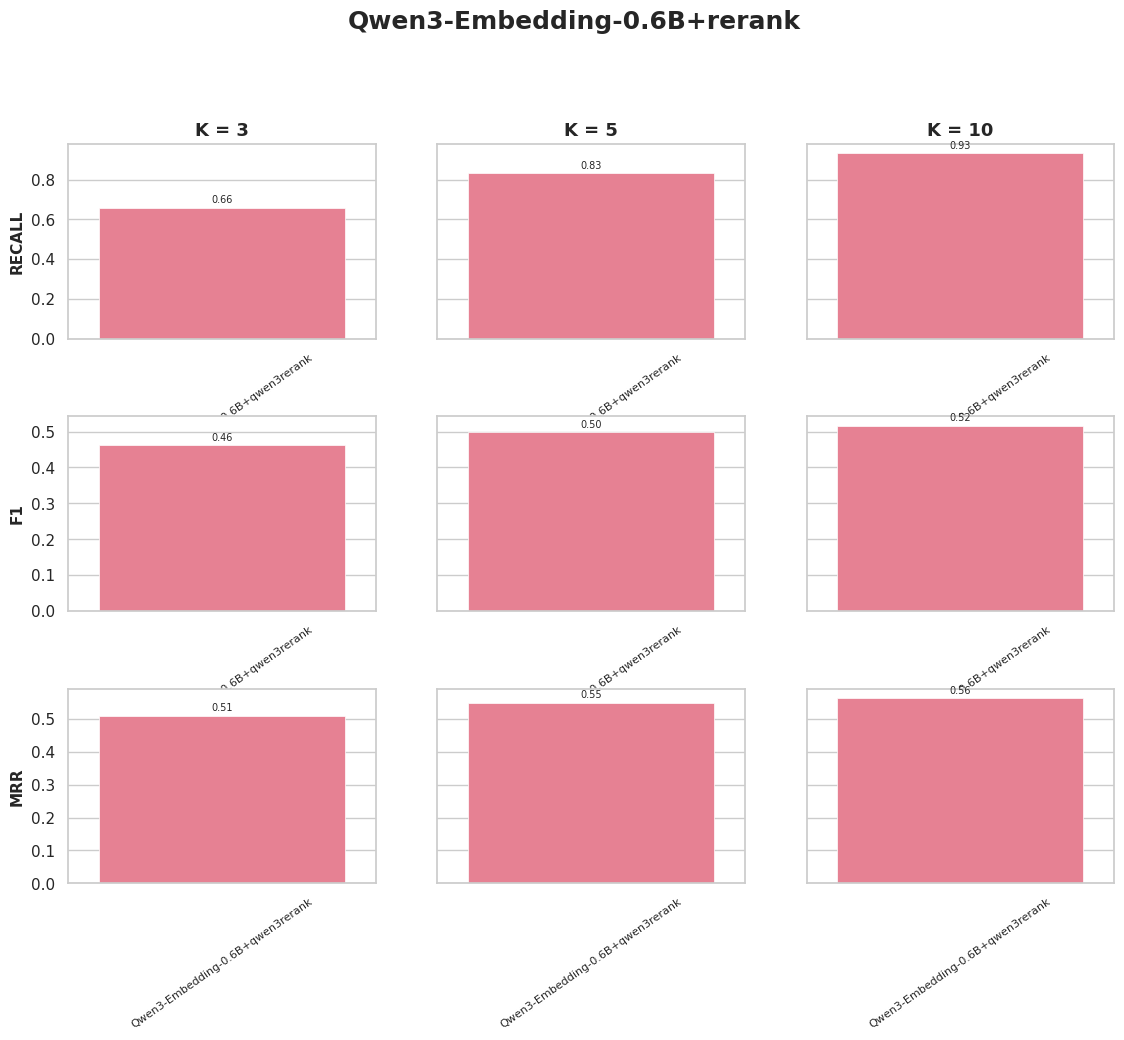

In [5]:
configs_sp = [
    RAGConfig(name="Qwen3-Embedding-0.6B+qwen3rerank", 
              chunking=ChunkingConfig(splitter_type="hierarchical", hierarchy_sizes=[512, 256, 128]),
              embedding=EmbeddingConfig(model_name="Qwen/Qwen3-Embedding-0.6B",
                                        api_model_name="qwen3-embed"),
              rerank=RerankConfig(enabled=True,
                                  model_name="jinaai/jina-reranker-v3",
                                  api_model_name="harr-rerank",
                                #   prompt_template="qwen3",
                                  backend="local_llm",
                                  top_n=10),
              recreate=False
              ),
]
results_sp = run_experiments(configs_sp, page_mapper, splitter_factory, eval_data,
                                   save_csv="./new_results/Qwen3-Embedding-0.6B-qwen3rerank.csv")
ResultsVisualizer.compare_categories(results_sp,
                                     title="Qwen3-Embedding-0.6B+rerank",
                                     category_col="experiment",
                                     k_values=[3,5,10],
                                     save_path="./new_results/Qwen3-Embedding-0.6B-qwen3rerank.png")

In [7]:
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "Qwen/Qwen3-Reranker-0.6B", padding_side="left"
)
model = AutoModelForSequenceClassification.from_pretrained(
    "Qwen/Qwen3-Reranker-0.6B",
    torch_dtype=torch.bfloat16,
).cuda().eval()

def format_input(query, doc):
    prefix = (
        '<|im_start|>system\n'
        'Judge whether the Document meets the requirements based on '
        'the Query and the Instruct provided. Note that the answer '
        'can only be "yes" or "no".<|im_end|>\n'
        '<|im_start|>user\n'
        '<Instruct>: Given a web search query, retrieve relevant '
        'passages that answer the query\n'
    )
    suffix = '<|im_end|>\n<|im_start|>assistant\n<think>\n\n</think>\n\n'
    return f"{prefix}<Query>: {query}\n<Document>: {doc}{suffix}"

# Подставь свои реальные данные
query = "ТВОЙ ЗАПРОС"
doc_good = "РЕЛЕВАНТНЫЙ ЧАНК"
doc_bad = "НЕРЕЛЕВАНТНЫЙ ЧАНК"

inputs = tokenizer(
    [format_input(query, doc_good), format_input(query, doc_bad)],
    padding=True, truncation=True, max_length=4096, return_tensors="pt",
).to("cuda")

with torch.no_grad():
    logits = model(**inputs).logits.squeeze()

print(f"Logits:  good={logits[0].item():.4f}  bad={logits[1].item():.4f}")
print(f"Sigmoid: good={logits[0].sigmoid().item():.4f}  bad={logits[1].sigmoid().item():.4f}")

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 6fa48482-b854-4a79-9edf-5a2957292f15)')' thrown while requesting HEAD https://huggingface.co/Qwen/Qwen3-Reranker-0.6B/resolve/main/tokenizer_config.json
2026-04-30 15:24:59,234 - WARNING - '(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 6fa48482-b854-4a79-9edf-5a2957292f15)')' thrown while requesting HEAD https://huggingface.co/Qwen/Qwen3-Reranker-0.6B/resolve/main/tokenizer_config.json
Retrying in 1s [Retry 1/5].
2026-04-30 15:24:59,234 - WARNING - Retrying in 1s [Retry 1/5].
Some weights of Qwen3ForSequenceClassification were not initialized from the model checkpoint at Qwen/Qwen3-Reranker-0.6B and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ValueError: Cannot handle batch sizes > 1 if no padding token is defined.

In [3]:
from sentence_transformers import CrossEncoder

model = CrossEncoder("tomaarsen/Qwen3-Reranker-0.6B-seq-cls", device="cuda", trust_remote_code=True)

def format_queries(query, instruction=None):
    prefix = '<|im_start|>system\nJudge whether the Document meets the requirements based on the Query and the Instruct provided. Note that the answer can only be "yes" or "no".<|im_end|>\n<|im_start|>user\n'
    if instruction is None:
        instruction = "Given a web search query, retrieve relevant passages that answer the query"
    return f"{prefix}<Instruct>: {instruction}\n<Query>: {query}\n"

def format_document(document):
    suffix = "<|im_end|>\n<|im_start|>assistant\n<think>\n\n</think>\n\n"
    return f"<Document>: {document}{suffix}"

task = "Given a web search query, retrieve relevant passages that answer the query"

queries = [
    "Which planet is known as the Red Planet?",
    "Which planet is known as the Red Planet?",
    "Which planet is known as the Red Planet?",
    "Which planet is known as the Red Planet?",
]
documents = [
    "Venus is often called Earth's twin because of its similar size and proximity.",
    "Mars, known for its reddish appearance, is often referred to as the Red Planet.",
    "Jupiter, the largest planet in our solar system, has a prominent red spot.",
    "Saturn, famous for its rings, is sometimes mistaken for the Red Planet.",
]

pairs = [[format_queries(q, task), format_document(d)] for q, d in zip(queries, documents)]
scores = model.predict(pairs)
print("Эталонный тест (ожидаем [0.04, 0.99, 0.41, 0.97]):")
print([round(s, 4) for s in scores.tolist()])

# Теперь тест на русском — ОЧЕВИДНАЯ разница
print("\n--- Тест на русском ---")
query_ru = "Какая планета называется Красной планетой?"
pairs_ru = [
    [format_queries(query_ru, task), format_document("Марс известен своим красноватым цветом и часто называется Красной планетой.")],
    [format_queries(query_ru, task), format_document("Вчера я купил новые кроссовки в магазине рядом с домом.")],
]
scores_ru = model.predict(pairs_ru)
print(f"Русский: релевантный={scores_ru[0]:.4f}  мусор={scores_ru[1]:.4f}")

# Тест с ТВОИМИ реальными данными
print("\n--- Тест с твоими данными ---")
# ПОДСТАВЬ СЮДА свой реальный запрос и чанки
query_real = "Какое действие считается моментом Активации ПВЗ?"
doc_real_good = docs[0].text
doc_real_bad = docs[1].text
pairs_real = [
    [format_queries(query_real, task), format_document(doc_real_good)],
    [format_queries(query_real, task), format_document(doc_real_bad)],
]
scores_real = model.predict(pairs_real)
print(f"Твои данные: good={scores_real[0]:.4f}  bad={scores_real[1]:.4f}")

# del model
# import gc, torch
# # del RAGConfig.rerank  # или reranker = None
# gc.collect()
# torch.cuda.empty_cache()

Batches: 100%|██████████| 1/1 [00:00<00:00,  5.55it/s]


Эталонный тест (ожидаем [0.04, 0.99, 0.41, 0.97]):
[0.0427, 0.9992, 0.4064, 0.9718]

--- Тест на русском ---


Batches: 100%|██████████| 1/1 [00:00<00:00, 29.69it/s]


Русский: релевантный=0.9953  мусор=0.0000

--- Тест с твоими данными ---


Batches: 100%|██████████| 1/1 [00:00<00:00,  9.83it/s]


Твои данные: good=0.9995  bad=0.0017


In [4]:
# Тест с ТВОИМИ реальными данными
print("\n--- Тест с твоими данными ---")
# ПОДСТАВЬ СЮДА свой реальный запрос и чанки
query_real = "Какое действие считается моментом Активации ПВЗ?"
doc_real_good = docs[0].text
doc_real_bad = docs[4].text
pairs_real = [
    [format_queries(query_real, task), format_document(doc_real_good)],
    [format_queries(query_real, task), format_document(doc_real_bad)],
]
scores_real = model.predict(pairs_real)
print(f"Твои данные: good={scores_real[0]:.4f}  bad={scores_real[1]:.4f}")


--- Тест с твоими данными ---


Batches: 100%|██████████| 1/1 [00:00<00:00, 11.87it/s]


Твои данные: good=0.9995  bad=0.0133


In [5]:
from experiments.rag_exp_new import *  # или скопируй _format_pair сюда


client = QdrantClient()

col_name = "wb_Qwen3-Embedding-0.6B+qwen3rerank"

vec_store = QdrantVectorStore(collection_name=col_name,
                              client=client)

Settings.embed_model = OpenAILikeEmbedding(
    model_name="qwen3-embed",  # или harr-embed — как у тебя в vLLM
    api_base="http://localhost:8081/v1",
)

index = VectorStoreIndex.from_vector_store(vector_store=vec_store)

# 1. Загрузи реранкер
# model = CrossEncoder("tomaarsen/Qwen3-Reranker-0.6B-seq-cls", device="cuda", trust_remote_code=True)

task = "Given a web search query, retrieve relevant passages that answer the query"

def format_queries(query, instruction=None):
    prefix = '<|im_start|>system\nJudge whether the Document meets the requirements based on the Query and the Instruct provided. Note that the answer can only be "yes" or "no".<|im_end|>\n<|im_start|>user\n'
    if instruction is None:
        instruction = task
    return f"{prefix}<Instruct>: {instruction}\n<Query>: {query}\n"

def format_document(document):
    suffix = "<|im_end|>\n<|im_start|>assistant\n<think>\n\n</think>\n\n"
    return f"<Document>: {document}{suffix}"

# 2. Возьми один запрос
query = eval_data[0]["query"]
relevant_pages = eval_data[0]["relevant_pages"]
print(f"Query: {query}")
print(f"Relevant pages: {relevant_pages}")

# 3. Достань кандидатов через retriever (как это делает run_experiment)
retriever = index.as_retriever(similarity_top_k=12)
print(retriever)
print(index)
candidates = retriever.retrieve(query)

print(f"\n--- До реранкинга (retriever scores) ---")
for i, n in enumerate(candidates):
    pages = n.metadata.get("pages_covered", [])
    is_rel = "✓" if set(pages) & set(relevant_pages) else "✗"
    print(f"  {i}: pages={pages} score={n.score:.4f} {is_rel}")

# 4. Прогони через реранкер ПРАВИЛЬНЫМ способом (из карточки модели)
pairs = [[format_queries(query, task), format_document(n.get_content())] for n in candidates]
scores = model.predict(pairs)

print(f"\n--- Scores реранкера (правильный формат) ---")
for i, (n, s) in enumerate(sorted(zip(candidates, scores), key=lambda x: x[1], reverse=True)):
    pages = n.metadata.get("pages_covered", [])
    is_rel = "✓" if set(pages) & set(relevant_pages) else "✗"
    print(f"  {i}: pages={pages} score={s:.4f} {is_rel}")

# 5. А теперь через _format_pair (как делает твой LocalReranker)
# from experiments.rag_exp import LocalReranker  # или скопируй _format_pair сюда

reranker = LocalReranker(
    "tomaarsen/Qwen3-Reranker-0.6B-seq-cls",
    top_n=10,
    device="cuda",
    prompt_template="qwen3",
)

# Посмотри что реально передаётся в model.predict
pairs_from_code = [reranker._format_pair(query, n.get_content()) for n in candidates]

# Сравни первую пару
print(f"\n--- Сравнение форматов ---")
print(f"Правильный query[:100]: {pairs[0][0][:100]}")
print(f"Из кода query[:100]:    {pairs_from_code[0][0][:100]}")
print(f"\nОдинаковые? {pairs[0][0] == pairs_from_code[0][0]}")
print(f"Правильный doc[:100]: {pairs[0][1][:100]}")
print(f"Из кода doc[:100]:    {pairs_from_code[0][1][:100]}")
print(f"\nОдинаковые? {pairs[0][1] == pairs_from_code[0][1]}")

# Scores через код
scores_from_code = reranker.model.predict(pairs_from_code)
print(f"\n--- Scores из кода ---")
for i, s in enumerate(scores_from_code):
    print(f"  {i}: правильный={scores[i]:.4f}  из_кода={s:.4f}  разница={abs(scores[i]-s):.6f}")

Query: Какое действие считается моментом Активации ПВЗ?
Relevant pages: ['1']

--- До реранкинга (retriever scores) ---
  0: pages=['7', '8'] score=0.7683 ✗
  1: pages=['1'] score=0.7176 ✓
  2: pages=['1'] score=0.6986 ✓
  3: pages=['7'] score=0.6851 ✗
  4: pages=['7', '8'] score=0.6830 ✗
  5: pages=['40'] score=0.6752 ✗
  6: pages=['1'] score=0.6666 ✓
  7: pages=['7', '8'] score=0.6591 ✗
  8: pages=['7'] score=0.6535 ✗
  9: pages=['40'] score=0.6467 ✗
  10: pages=['12'] score=0.6327 ✗
  11: pages=['35'] score=0.6307 ✗


Batches: 100%|██████████| 1/1 [00:00<00:00,  8.89it/s]



--- Scores реранкера (правильный формат) ---
  0: pages=['1'] score=0.9999 ✓
  1: pages=['1'] score=0.9998 ✓
  2: pages=['1'] score=0.9998 ✓
  3: pages=['7', '8'] score=0.9998 ✗
  4: pages=['7', '8'] score=0.9997 ✗
  5: pages=['7', '8'] score=0.9997 ✗
  6: pages=['7'] score=0.9966 ✗
  7: pages=['12'] score=0.9951 ✗
  8: pages=['35'] score=0.9894 ✗
  9: pages=['40'] score=0.9771 ✗
  10: pages=['40'] score=0.8878 ✗
  11: pages=['7'] score=0.6400 ✗


2026-05-01 13:24:05,940 - INFO - Reranker loaded: tomaarsen/Qwen3-Reranker-0.6B-seq-cls on cuda



--- Сравнение форматов ---
Правильный query[:100]: <|im_start|>system
Judge whether the Document meets the requirements based on the Query and the Inst
Из кода query[:100]:    <|im_start|>system
Judge whether the Document meets the requirements based on the Query and the Inst

Одинаковые? True
Правильный doc[:100]: <Document>: Активация ПВЗ происходит с момента
получения Исполнителем сообщения об активации, и ПВЗ 
Из кода doc[:100]:    <Document>: Активация ПВЗ происходит с момента
получения Исполнителем сообщения об активации, и ПВЗ 

Одинаковые? True


Batches: 100%|██████████| 1/1 [00:00<00:00,  8.79it/s]



--- Scores из кода ---
  0: правильный=0.9997  из_кода=0.9997  разница=0.000000
  1: правильный=0.9999  из_кода=0.9999  разница=0.000000
  2: правильный=0.9998  из_кода=0.9998  разница=0.000000
  3: правильный=0.9966  из_кода=0.9966  разница=0.000000
  4: правильный=0.9997  из_кода=0.9997  разница=0.000000
  5: правильный=0.9771  из_кода=0.9771  разница=0.000000
  6: правильный=0.9998  из_кода=0.9998  разница=0.000000
  7: правильный=0.9998  из_кода=0.9998  разница=0.000000
  8: правильный=0.6400  из_кода=0.6400  разница=0.000000
  9: правильный=0.8878  из_кода=0.8878  разница=0.000000
  10: правильный=0.9951  из_кода=0.9951  разница=0.000000
  11: правильный=0.9894  из_кода=0.9894  разница=0.000000


In [4]:
from transformers import AutoModel
import torch

model = AutoModel.from_pretrained(
    "jinaai/jina-reranker-v3",
    dtype="auto",
    trust_remote_code=True,
).cuda().eval()

# Тест на английском (из документации)
query = "Which planet is known as the Red Planet?"
documents = [
    "Venus is often called Earth's twin.",
    "Mars is often referred to as the Red Planet.",
    "Jupiter has a prominent red spot.",
]
results = model.rerank(query, documents, top_n=3)
print("Английский:")
for r in results:
    print(f"  doc={r['index']} score={r['relevance_score']:.4f}: {documents[r['index']][:60]}")

# Тест на русском (твои данные)
print("\nРусский:")
query_ru = "Какое действие считается моментом Активации ПВЗ?"
doc_good = docs[0].text[:400]
doc_bad = docs[3].text[:400]
results_ru = model.rerank(query_ru, [doc_good, doc_bad], top_n=2)
for r in results_ru:
    print(f"  doc={r['index']} score={r['relevance_score']:.4f}")

Английский:
  doc=1 score=0.4630: Mars is often referred to as the Red Planet.
  doc=2 score=-0.0226: Jupiter has a prominent red spot.
  doc=0 score=-0.0604: Venus is often called Earth's twin.

Русский:
  doc=0 score=0.3983
  doc=1 score=-0.0710


In [8]:
from experiments.rag_exp_new import *  # или скопируй _format_pair сюда


client = QdrantClient()

col_name = "wb_Qwen3-Embedding-0.6B+qwen3rerank"

vec_store = QdrantVectorStore(collection_name=col_name,
                              client=client)

Settings.embed_model = OpenAILikeEmbedding(
    model_name="qwen3-embed",  # или harr-embed — как у тебя в vLLM
    api_base="http://localhost:8081/v1",
)

index = VectorStoreIndex.from_vector_store(vector_store=vec_store)


# Те же candidates, что ты уже доставал ранее
query = eval_data[0]["query"]
relevant_pages = eval_data[0]["relevant_pages"]

retriever = index.as_retriever(similarity_top_k=12)
candidates = retriever.retrieve(query)
texts = [n.get_content() for n in candidates]

# Jina v3 — все документы сразу
results_jina = model.rerank(query, texts, top_n=12)

print("--- Jina v3 scores ---")
for r in results_jina:
    n = candidates[r["index"]]
    pages = n.metadata.get("pages_covered", [])
    is_rel = "✓" if set(pages) & set(relevant_pages) else "✗"
    print(f"  pages={pages} score={r['relevance_score']:.4f} {is_rel}")

--- Jina v3 scores ---
  pages=['1'] score=0.3038 ✓
  pages=['7', '8'] score=0.2510 ✗
  pages=['1'] score=0.2349 ✓
  pages=['1'] score=0.1893 ✓
  pages=['7', '8'] score=0.1265 ✗
  pages=['7', '8'] score=0.0648 ✗
  pages=['12'] score=0.0450 ✗
  pages=['7'] score=0.0282 ✗
  pages=['40'] score=-0.0209 ✗
  pages=['7'] score=-0.0284 ✗
  pages=['35'] score=-0.0473 ✗
  pages=['40'] score=-0.0852 ✗
